# Библиотеки

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

## 7.5 Меры центральной тенденции: среднее, мода, медиана

In [5]:
k = pd.read_spss('./data/SPSS11.sav')

In [16]:
k

,КОТ,Пол,Атрибут1,Атрибут2
0,33.0,М,1.0,3.0
1,45.0,М,1.0,4.0
2,47.0,М,1.0,4.0
3,36.0,М,1.0,4.0
4,46.0,М,1.0,4.0
...,...,...,...,...
640,44.0,Ж,10.0,10.0
641,57.0,Ж,10.0,10.0
642,42.0,Ж,10.0,10.0
643,47.0,Ж,10.0,10.0


In [7]:
k.mean(numeric_only=True)

,КОТ,Атрибут1,Атрибут2
0,51.0,6.0,6.0


In [8]:
k.median(numeric_only=True)

КОТ         49.0
Атрибут1     6.0
Атрибут2     6.0
dtype: float64

In [9]:
k.mode(numeric_only=True)

,КОТ,Атрибут1,Атрибут2
0,51.0,6.0,6.0


In [10]:
k[['КОТ','Атрибут1','Атрибут2']].mean()

КОТ         48.035659
Атрибут1     5.728682
Атрибут2     5.860465
dtype: float64

In [11]:
k[['КОТ','Атрибут1','Атрибут2']].median()

КОТ         49.0
Атрибут1     6.0
Атрибут2     6.0
dtype: float64

In [12]:
k[['КОТ','Атрибут1','Атрибут2']].mode()

,КОТ,Атрибут1,Атрибут2
0,51.0,6.0,6.0


In [15]:
k.pivot_table(values=['КОТ','Атрибут1','Атрибут2'],index='Пол',aggfunc=['mean', 'median'], observed=True)

mean                        median               
     Атрибут1  Атрибут2        КОТ Атрибут1 Атрибут2   КОТ
Пол                                                       
Ж    7.096317  6.699717  47.886686      8.0      7.0  49.0
М    4.075342  4.845890  48.215753      4.0      5.0  49.0

## 7.7 Меры рассеивания\вариативности: дисперсия, ст.отклонение, размах

In [17]:
k[['Атрибут1','Атрибут2']].max()-k[['Атрибут1','Атрибут2']].min()

Атрибут1    9.0
Атрибут2    9.0
dtype: float64

In [18]:
k[['Атрибут1','Атрибут2']].std()

Атрибут1    2.895574
Атрибут2    2.352296
dtype: float64

In [20]:
k.groupby('Пол', observed=True)[['Атрибут1','Атрибут2']].std()

,Атрибут1,Атрибут2
Пол,,
Ж,2.540985,2.192556
М,2.394397,2.131473


In [22]:
k.pivot_table(values=['Атрибут1','Атрибут2'],index='Пол',aggfunc=['mean', 'median', 'var', 'std'], observed=True).T

Пол                     Ж         М
mean   Атрибут1  7.096317  4.075342
       Атрибут2  6.699717  4.845890
median Атрибут1  8.000000  4.000000
       Атрибут2  7.000000  5.000000
var    Атрибут1  6.456606  5.733136
       Атрибут2  4.807301  4.543179
std    Атрибут1  2.540985  2.394397
       Атрибут2  2.192556  2.131473

## 7.11 Меры формы распределения: асимметрия и эксцесс

In [23]:
k[['Атрибут1','Атрибут2']].skew()

Атрибут1   -0.108375
Атрибут2   -0.198243
dtype: float64

In [24]:
k[['Атрибут1','Атрибут2']].kurt()

Атрибут1   -1.232921
Атрибут2   -0.702917
dtype: float64

In [38]:
pd.DataFrame({
    'Атрибут1': k['Атрибут1'].value_counts().sort_index(),
    'Атрибут2': k['Атрибут2'].value_counts().sort_index()
})

,Атрибут1,Атрибут2
1.0,60,29
2.0,57,33
3.0,63,45
4.0,61,82
5.0,50,84
6.0,78,108
7.0,56,88
8.0,76,78
9.0,70,66
10.0,74,32


<Axes: xlabel='Атрибут1'>

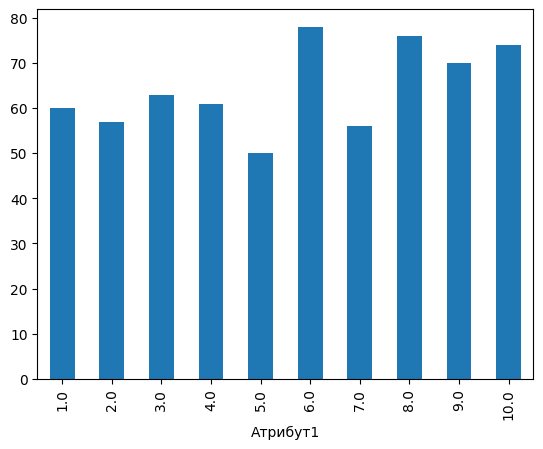

In [42]:
k['Атрибут1'].value_counts().sort_index().plot.bar()

<Axes: xlabel='Атрибут2'>

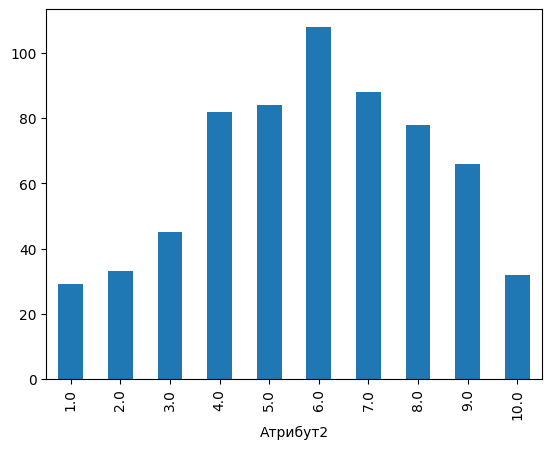

In [43]:
k['Атрибут2'].value_counts().sort_index().plot.bar()

In [45]:
k.groupby("Пол", observed=False)[["Атрибут1","Атрибут2"]].agg(["mean","median","std","skew", pd.Series.kurt]).T

Пол                     Ж         М
Атрибут1 mean    7.096317  4.075342
         median  8.000000  4.000000
         std     2.540985  2.394397
         skew   -0.623628  0.317289
         kurt   -0.755606 -1.028346
Атрибут2 mean    6.699717  4.845890
         median  7.000000  5.000000
         std     2.192556  2.131473
         skew   -0.583887  0.127668
         kurt   -0.089951 -0.558509

In [46]:
pd.crosstab(k["Атрибут1"], k["Пол"])

Пол,Ж,М
Атрибут1,,
1.0,6,54
2.0,12,45
3.0,26,37
4.0,27,34
5.0,27,23
6.0,32,46
7.0,30,26
8.0,57,19
9.0,64,6


In [47]:
pd.crosstab(k["Атрибут2"], k["Пол"])

Пол,Ж,М
Атрибут2,,
1.0,10,19
2.0,7,26
3.0,15,30
4.0,23,59
5.0,37,47
6.0,58,50
7.0,67,21
8.0,51,27
9.0,56,10


<Axes: xlabel='Атрибут1'>

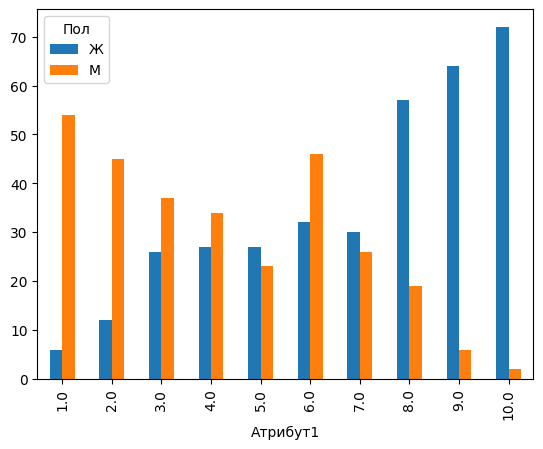

In [48]:
pd.crosstab(k["Атрибут1"], k["Пол"]).plot.bar()

<Axes: xlabel='Атрибут2'>

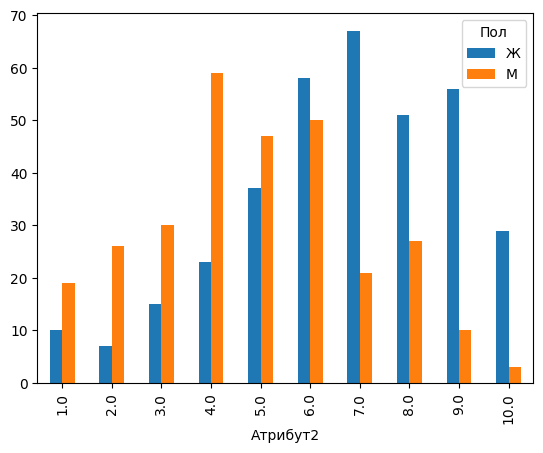

In [49]:
pd.crosstab(k["Атрибут2"], k["Пол"]).plot.bar()

# end